# 02 — Postprocessing Pipeline

**Goal:** Systematically evaluate morphological and object-based postprocessing strategies
on the PA2 SVM Hybrid prediction map to reduce salt-and-pepper noise and improve
the operational F1 score (baseline: 0.27–0.41).

## Methods compared
| ID | Method | Description |
|---|---|---|
| A | Baseline | No postprocessing — raw SVM prediction |
| B | Median 3×3 | Removes isolated single-pixel noise |
| C | Morphological | Binary open/close + minimum area filter |
| D | SLIC majority vote | Object-based smoothing (superpixels from AFTER image) |
| E | Morphological + SLIC | Best of both worlds |

**Evaluation scene:** 2020-08-12 (same as PA2 final evaluation — allows direct comparison)  
**Tuning scene:** Use 2019-06-23 to tune filter parameters if needed (never touch the eval scene).

---
## Setup

In [17]:
import sys
import os
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Add project root to path so src/ imports work
sys.path.insert(0, os.path.abspath('..'))

from src.postprocessing import postprocess_prediction
from src.evaluation import evaluate_and_visualize

In [18]:
# --- Paths ---
# PA2 prediction map (baseline — no postprocessing)
PRED_MAP_PATH = r'C:\Workspace\ZHAW\5_Semester\airport-mowing-detection\docs\images\pred_map_2020-08-12_tuned_svm_hybrid.tif'

# Ground truth masks for the 2020-08-12 scene
# Multiple events may fall on the same date — list them all
MASKS_DIR  = r'..\data\ground_truth_masks'
GT_MASKS   = []  # filled dynamically below from temporal_matches.csv

# Sentinel-2 AFTER image for 2020-08-12 (used as SLIC input + background)
SENTINEL_DIR = r'..\data\Sentinel_CH'
AFTER_IMG    = os.path.join(SENTINEL_DIR, '2020-08-12.tif')  # adjust if filename differs

# Output directory
OUTPUT_DIR = r'..\data\postprocessing_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [19]:
# Find all ground truth masks whose after_file is 2020-08-12
matches_df = pd.read_csv(r'..\data\temporal_matches.csv')

gt_rows = matches_df[matches_df['after_file'].str.startswith('2020-08-12')]
GT_MASKS = gt_rows['mask_file'].tolist()

print(f"Ground truth masks for 2020-08-12: {GT_MASKS}")
print(f"After image exists: {os.path.exists(AFTER_IMG)}")
print(f"Prediction map exists: {os.path.exists(PRED_MAP_PATH)}")

Ground truth masks for 2020-08-12: ['mask_20200810.tif', 'mask_20200811.tif']
After image exists: True
Prediction map exists: True


---
## 1. Load Baseline Prediction

In [20]:
with rasterio.open(PRED_MAP_PATH) as src:
    pred_baseline = src.read(1)
    meta = src.meta.copy()
    transform = src.transform

print(f"Shape: {pred_baseline.shape}")
print(f"Unique values: {np.unique(pred_baseline)}")
print(f"Mowed pixels (1): {(pred_baseline == 1).sum():,}")
print(f"Not-mowed pixels (0): {(pred_baseline == 0).sum():,}")
print(f"No-data pixels (-1): {(pred_baseline == -1).sum():,}")

Shape: (559, 381)
Unique values: [-1  0  1]
Mowed pixels (1): 12,473
Not-mowed pixels (0): 21,295
No-data pixels (-1): 179,211


In [21]:
# Load combined ground truth for the eval scene
height, width = pred_baseline.shape
gt_combined = np.zeros((height, width), dtype=np.uint8)
for mask_name in GT_MASKS:
    mask_path = os.path.join(MASKS_DIR, mask_name)
    if os.path.exists(mask_path):
        with rasterio.open(mask_path) as src:
            gt_combined = np.maximum(gt_combined, src.read(1))

print(f"GT mowed pixels: {gt_combined.sum():,}")

GT mowed pixels: 2,252


---
## 2. Evaluation Helper

In [22]:
def compute_metrics(pred_map, gt_map, label=''):
    """Pixel-level precision/recall/F1 for the 'Mowed' class."""
    valid = pred_map != -1
    y_pred = pred_map[valid]
    y_true = gt_map[valid]
    report = classification_report(
        y_true, y_pred, target_names=['No Mowing', 'Mowing'], output_dict=True
    )
    m = {
        'Method': label,
        'Precision': report['Mowing']['precision'],
        'Recall':    report['Mowing']['recall'],
        'F1':        report['Mowing']['f1-score'],
        'Mowed_pixels': int((pred_map == 1).sum()),
    }
    return m

results = []

---
## 3. Method A — Baseline (no postprocessing)

In [23]:
m = compute_metrics(pred_baseline, gt_combined, label='A — Baseline')
results.append(m)
print(f"Precision: {m['Precision']:.3f}  Recall: {m['Recall']:.3f}  F1: {m['F1']:.3f}  Mowed px: {m['Mowed_pixels']:,}")

Precision: 0.162  Recall: 0.897  F1: 0.274  Mowed px: 12,473


---
## 4. Method B — Median Filter 3×3

In [24]:
pred_median = postprocess_prediction(pred_baseline, method='median', median_size=3)

m = compute_metrics(pred_median, gt_combined, label='B — Median 3×3')
results.append(m)
print(f"Precision: {m['Precision']:.3f}  Recall: {m['Recall']:.3f}  F1: {m['F1']:.3f}  Mowed px: {m['Mowed_pixels']:,}")

Precision: 0.199  Recall: 0.895  F1: 0.325  Mowed px: 10,131


---
## 5. Method C — Morphological Open/Close + Area Filter

In [25]:
pred_morph = postprocess_prediction(pred_baseline, method='morphological',
                                     disk_radius=2, min_area_pixels=4)

m = compute_metrics(pred_morph, gt_combined, label='C — Morphological')
results.append(m)
print(f"Precision: {m['Precision']:.3f}  Recall: {m['Recall']:.3f}  F1: {m['F1']:.3f}  Mowed px: {m['Mowed_pixels']:,}")

Precision: 0.331  Recall: 0.784  F1: 0.466  Mowed px: 5,321


---
## 6. Method D — SLIC Superpixel Majority Vote

Requires scikit-image (`pip install scikit-image`).

In [26]:
# Load AFTER image bands and normalise to [0,1] for SLIC
with rasterio.open(AFTER_IMG) as src:
    # Use Blue(1), Green(2), Red(3), NIR(7), SWIR(10) — same as feature engineering
    bands = np.stack([
        np.clip(src.read(1) / 3000.0, 0, 1),
        np.clip(src.read(2) / 3000.0, 0, 1),
        np.clip(src.read(3) / 3000.0, 0, 1),
        np.clip(src.read(7) / 5000.0, 0, 1),
        np.clip(src.read(10) / 5000.0, 0, 1),
    ], axis=-1)  # shape (H, W, 5)

print(f"Scene image shape: {bands.shape}  dtype: {bands.dtype}")

Scene image shape: (559, 381, 5)  dtype: float32


In [27]:
pred_slic = postprocess_prediction(pred_baseline, method='slic',
                                    scene_image=bands,
                                    n_segments=300, slic_compactness=0.05)

m = compute_metrics(pred_slic, gt_combined, label='D — SLIC (n=300)')
results.append(m)
print(f"Precision: {m['Precision']:.3f}  Recall: {m['Recall']:.3f}  F1: {m['F1']:.3f}  Mowed px: {m['Mowed_pixels']:,}")

Precision: 0.198  Recall: 0.514  F1: 0.286  Mowed px: 5,831


---
## 7. Method E — Morphological + SLIC

In [28]:
pred_morph_slic = postprocess_prediction(pred_baseline, method='morphological+slic',
                                          scene_image=bands,
                                          disk_radius=2, min_area_pixels=4,
                                          n_segments=300, slic_compactness=0.05)

m = compute_metrics(pred_morph_slic, gt_combined, label='E — Morphological + SLIC')
results.append(m)
print(f"Precision: {m['Precision']:.3f}  Recall: {m['Recall']:.3f}  F1: {m['F1']:.3f}  Mowed px: {m['Mowed_pixels']:,}")

Precision: 0.502  Recall: 0.514  F1: 0.508  Mowed px: 2,305


---
## 8. Summary Table

In [29]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Method')
results_df = results_df.round(3)
print(results_df.to_string())
results_df.to_csv(os.path.join(OUTPUT_DIR, 'postprocessing_comparison.csv'))

                          Precision  Recall     F1  Mowed_pixels
Method                                                          
A — Baseline                  0.162   0.897  0.274         12473
B — Median 3×3                0.199   0.895  0.325         10131
C — Morphological             0.331   0.784  0.466          5321
D — SLIC (n=300)              0.198   0.514  0.286          5831
E — Morphological + SLIC      0.502   0.514  0.508          2305


---
## 9. Visual Comparison

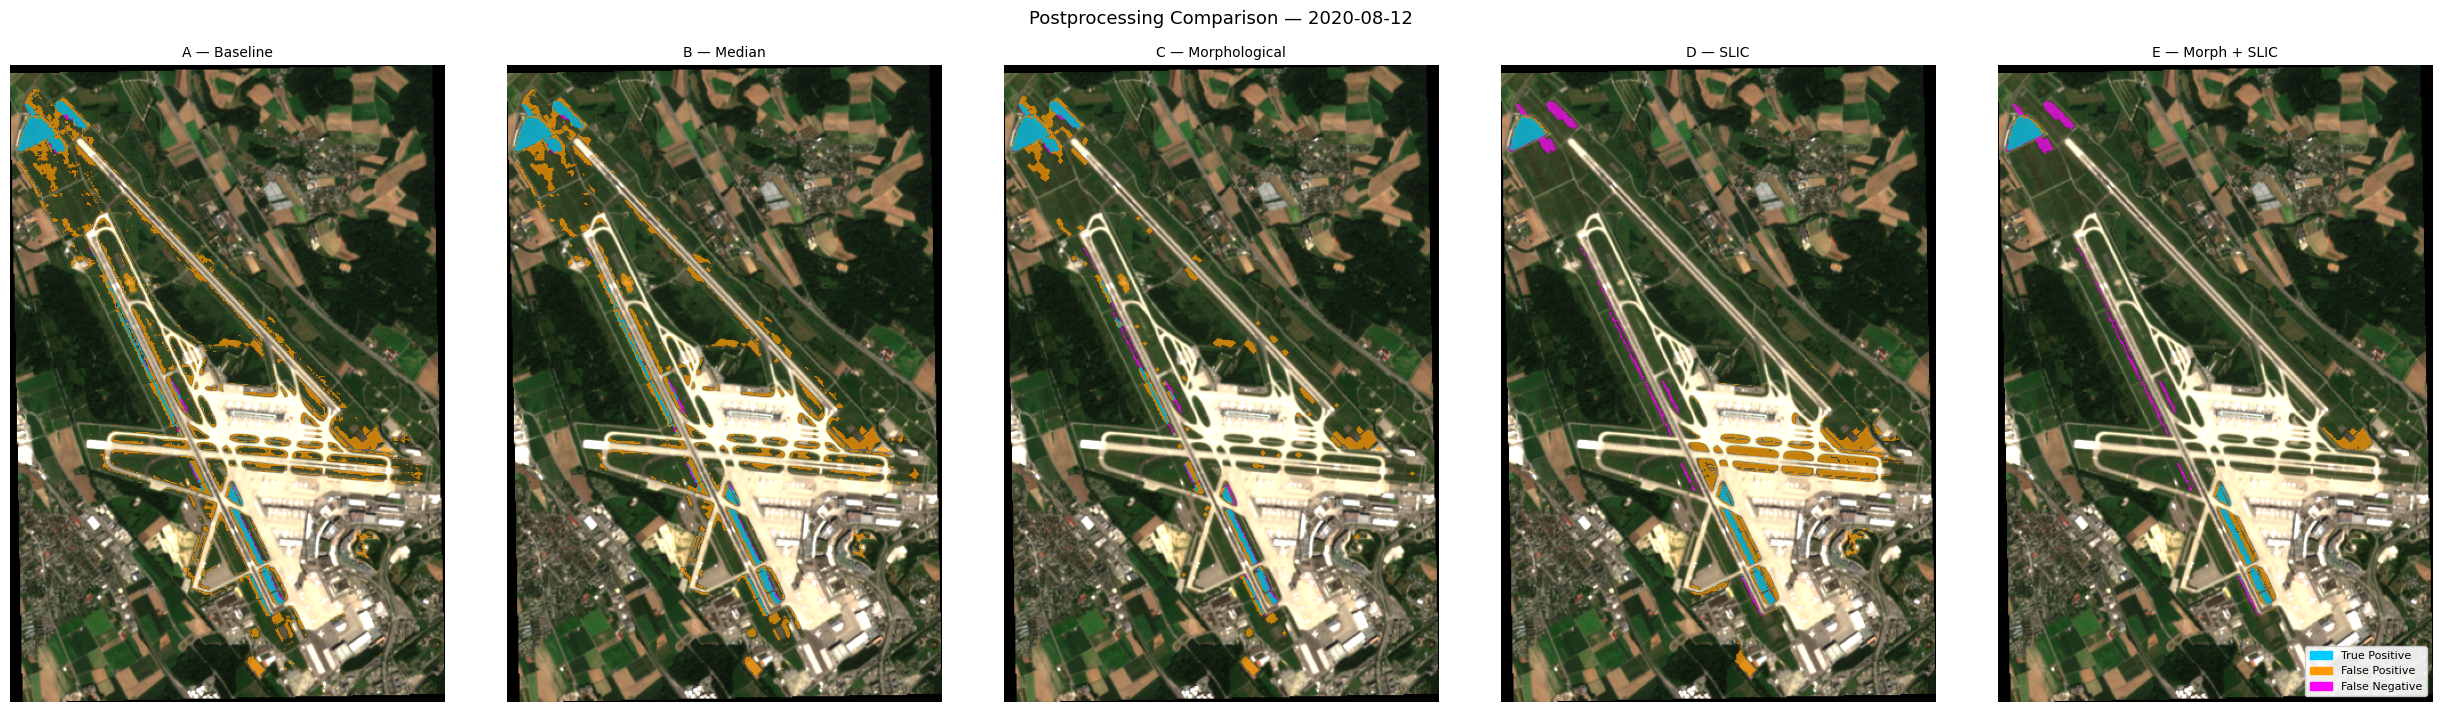

In [14]:
def make_diff_map(pred_map, gt_map):
    """Returns TP=1, FP=2, FN=3, NaN elsewhere."""
    diff = np.full(pred_map.shape, np.nan)
    diff[(pred_map == 1) & (gt_map == 1)] = 1
    diff[(pred_map == 1) & (gt_map == 0)] = 2
    diff[(pred_map == 0) & (gt_map == 1)] = 3
    return diff


# Load RGB background
with rasterio.open(AFTER_IMG) as src:
    rgb = np.dstack([
        np.clip(src.read(3) / 2500, 0, 1),
        np.clip(src.read(2) / 2500, 0, 1),
        np.clip(src.read(1) / 2500, 0, 1),
    ])

cmap = ListedColormap(['#00CCFF', '#FF9900', '#FF00FF'])
legend_patches = [
    mpatches.Patch(color='#00CCFF', label='True Positive'),
    mpatches.Patch(color='#FF9900', label='False Positive'),
    mpatches.Patch(color='#FF00FF', label='False Negative'),
]

pred_maps = [
    ('A — Baseline', pred_baseline),
    ('B — Median', pred_median),
    ('C — Morphological', pred_morph),
    ('D — SLIC', pred_slic),
    ('E — Morph + SLIC', pred_morph_slic),
]

fig, axes = plt.subplots(1, len(pred_maps), figsize=(5 * len(pred_maps), 7))

for ax, (title, pm) in zip(axes, pred_maps):
    ax.imshow(rgb)
    ax.imshow(make_diff_map(pm, gt_combined), cmap=cmap, vmin=0.5, vmax=3.5, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

axes[-1].legend(handles=legend_patches, loc='lower right', fontsize=8, framealpha=0.9)
plt.suptitle('Postprocessing Comparison — 2020-08-12', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'postprocessing_visual_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save Best Postprocessed Prediction

Update `BEST_METHOD` based on the F1 scores above.

In [ ]:
# Choose the best method by F1 score
best_row = results_df['F1'].idxmax()
print(f"Best method: {best_row}  (F1={results_df.loc[best_row, 'F1']:.3f})")

# Map method label back to prediction array
method_map = {
    'A — Baseline':           pred_baseline,
    'B — Median 3×3':         pred_median,
    'C — Morphological':      pred_morph,
    'D — SLIC (n=300)':       pred_slic,
    'E — Morphological + SLIC': pred_morph_slic,
}
best_pred = method_map[best_row]

# Save to TIF
save_path = os.path.join(OUTPUT_DIR, 'pred_map_2020-08-12_best_postprocessed.tif')
with rasterio.open(save_path, 'w', **meta) as dst:
    dst.write(best_pred, 1)
print(f"Saved: {save_path}")

---
## Notes / Decision Gate

- If morphological alone (Method C) brings F1 > 0.5, SLIC (Method D/E) is a bonus.
- The best-performing method's function call should be imported in later notebooks
  (05_feature_fusion, 07_model_application_fusion) via:

```python
from src.postprocessing import postprocess_prediction
postprocess_fn = lambda pred: postprocess_prediction(pred, method='morphological', ...)
```

- **Parameter tuning**: if you want to tune disk_radius or n_segments,
  use the 2019-06-23 scene (first match in temporal_matches.csv),
  NOT the 2020-08-12 eval scene.

## Feedback Gemini

Bevor du das als finale Methode absegnest, solltest du eine kleine Parameter-Studie (**Grid Search**) für das Postprocessing machen. Spiele mit den Werten `disk_radius, min_area_pixels und n_segments`. Dein Ziel ist es, den "Sweet Spot" zu finden, wo die Precision hochgeht, der Recall aber nicht unter 70-80% fällt.


Additional methods to consider:

- Conditional Random Fields (CRF) — a classic spatial smoothing approach that respects edges, often outperforms morphological methods on field boundaries
- Majority voting with larger windows — simpler than SLIC but sometimes surprisingly effective
- Gaussian smoothing before classification — pre-classification rather than post
- Superpixel alternatives to SLIC — e.g., SEEDS or SNIC, which may segment grassland patches more naturally